# Библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.data import DataLoader
from torchvision.models import resnet18
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
import torchvision.transforms.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dicom
import matplotlib.pyplot as plt
from skimage.io import imread
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path
from torchvision import transforms as tfs
from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from matplotlib import colors, pyplot as plt
%matplotlib inline


import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)
from collections import defaultdict

C:\Users\12345654321\anaconda3\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.3'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
import numpy as np
import pandas as pd

import random
from glob import glob
import os, shutil
from tqdm import tqdm
tqdm.pandas()
import time
import copy
import joblib
from collections import defaultdict
import gc
from IPython import display as ipd

# visualization
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Sklearn
from sklearn.model_selection import StratifiedKFold, KFold, StratifiedGroupKFold

# PyTorch 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torch.cuda import amp

import timm

# Albumentations for augmentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

import rasterio
from joblib import Parallel, delayed

# For colored terminal text
from colorama import Fore, Back, Style
c_  = Fore.GREEN
sr_ = Style.RESET_ALL

import warnings
warnings.filterwarnings("ignore")

# For descriptive error messages
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

import pydicom as dicom
import nibabel as nib
import sys
import glob
import os
import numpy as np
import h5py
from sklearn.preprocessing import StandardScaler

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torch.cuda import amp

import timm

from torchvision import transforms as T

# Загрузка и обработка данных

In [5]:
def load_tif_mask(x_path, mask_pth):# скачиваем снимки и размечаем: с маской - 1, без - 0
    images = []
    labels = []
    image = Image.open(x_path)
    mask = Image.open(mask_pth)
    i = 0
    
    while True:
        try:
            mask.seek(i)
            mask_array = np.array(mask)
            image.seek(i)
            image_array = np.array(image)
            images.append(image_array)
            if sum(sum(mask_array)) > 0:
                labels.append(1)
            else:
                labels.append(0)
            i += 1
        except EOFError:
            break
    num_of_imgs = i
    
    return images, labels, num_of_imgs

In [10]:
def get_images_mask(x_pathes, y_pathes):

    images =[]
    labels = []
    num_of_ims = []

    for x_path, y_path in zip(x_pathes, y_pathes):

        images_sample,mask_sample, num_of_imgs = load_tif_mask(x_path, y_path)
        num_of_ims.append(num_of_imgs)
        for im,ms in zip(images_sample,mask_sample):
          
            images.append(im)
            labels.append(ms)
                            
    return images, labels, num_of_ims

In [12]:
def get_pathes_mask(path): 
    x_pathes_all = []
    y_pathes_all = []

    counter = 0
    for patient in os.listdir(path):
        x_pathes = []
        y_pathes = []
      
        for ID_s in os.listdir(path + '/'+ patient ):
            if 'ID' in ID_s:
                msk_t1 = 0  
                for tif_name in os.listdir(path + '/'+ patient + '/'+ID_s):
    
                    if 'ax' in tif_name.lower():
                        if 'T1' or 'FSPGR' in tif_name:
            
                            if  'mask' not in tif_name.lower():
                                x_pathes.append(path + '/'+ patient + '/' + ID_s + '/'+ tif_name)

                            elif 'mask' in tif_name.lower():
                                msk_t1 = 1
                                y_pathes.append(path + '/'+ patient + '/'+ID_s + '/' + tif_name)
                        
                if msk_t1==0:
                    x_pathes.pop()
                        
        x_pathes_all.append(x_pathes)
        y_pathes_all.append(y_pathes)
        counter+= 1
        if (counter >= 100):
            break
                                
    return x_pathes_all, y_pathes_all

In [14]:
#x_pth ,y_pth = get_pathes_mask('C:/Users/12345654321/data_pituitary_test')
x_pth ,y_pth = get_pathes_mask('C:/Users/12345654321/data_pituitary_18_01_25')

In [16]:
def flatten(xss):
    return [x for xs in xss for x in xs]

In [18]:
x_pth_train,x_pth_val,y_pth_train,y_pth_val = train_test_split(x_pth , y_pth, test_size=0.25)

x_pth_train,y_pth_train,x_pth_val,y_pth_val = flatten(x_pth_train) ,flatten(y_pth_train),flatten(x_pth_val),flatten(y_pth_val)

In [20]:
x_val,y_val, ni_val = get_images_mask(x_pth_val ,y_pth_val) 
x_train,y_train, ni_train = get_images_mask(x_pth_train ,y_pth_train)

# Формируем датасет

In [22]:
class BuildDataset(torch.utils.data.Dataset):
    def __init__(self, X,y, mode='train', transforms=None):
   
        self.mode      = mode
        self.img_paths  = X
        self.labels_paths  = y
        self.transforms = transforms
        self.knsop_labels = {'0':0,'1':1}

    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, index):

        img = self.img_paths[index]
        
        if self.mode == 'test':
            data = self.transforms(image=np.array(img, dtype=np.float32))
            img  = data['image']
            img = torch.tensor(img)
            img = img[None,:,:]
            sample = {
            "image": img,
            }
        else:
            data = self.transforms(image=np.array(img, dtype=np.float32))
            img  = data['image']
            img = torch.tensor(img)
            img = img[None,:,:]
            y = self.labels_paths[index]
            Right = self.knsop_labels[str(y)]
            sample = {
            "image":img,
            "labelS":Right
            }
        return sample

In [24]:
data_transforms = {
    "train": A.Compose([
        A.Resize(512,512, interpolation=cv2.INTER_NEAREST),
        A.augmentations.crops.transforms.CenterCrop(256,256),
        A.Resize(224,224, interpolation=cv2.INTER_NEAREST),
        # A.HorizontalFlip(p=0.5),
        # A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.0225, scale_limit=0.005, rotate_limit=10, p=1.),
        A.OneOf([
            A.GridDistortion(num_steps=5, distort_limit=0.05, p=1.0),
# #             A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=1.0),
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)
        ], p=0.25),
        A.CoarseDropout(max_holes=8, max_height=224//20, max_width=224//20,
                         min_holes=5, fill_value=0, mask_fill_value=0, p=1.0),
        A.augmentations.Normalize(mean=(0.485, ), std=(0.229, )),
        ]
        , p=1.0),
    
    "valid": A.Compose([
        A.Resize(512,512, interpolation=cv2.INTER_NEAREST),
        A.augmentations.crops.transforms.CenterCrop(256,256),
        A.Resize(224,224, interpolation=cv2.INTER_NEAREST),
        A.augmentations.Normalize(mean=(0.485, ), std=(0.229, )),
        ], p=1.0)
}

In [26]:
train_dataset = BuildDataset(x_train, y_train, transforms=data_transforms['train'])
val_dataset = BuildDataset(x_val,y_val, transforms=data_transforms['valid'])

train_loader = DataLoader(train_dataset, batch_size=128,shuffle=True)
valid_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# Модель

In [29]:
DEVICE='cuda'

In [31]:
def accuracy(y_true, y_pred):
    correct_predictions = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == yp:
            correct_predictions += 1
    return correct_predictions / len(y_true)



def recall_score_multiclass(y_true, y_pred, num_classes=6):
    recall = np.zeros(num_classes)
    for c in range(num_classes):
        true_positives = ((y_true == c) & (y_pred == c)).sum().item()
        possible_positives = (y_true == c).sum().item()
        recall[c] = true_positives / (possible_positives + 1e-7)
    return recall.mean()

def accuracy_score_multiclass(y_true, y_pred):
    correct_predictions = (y_true == y_pred).sum().item()
    accuracy = correct_predictions / y_true.numel()
    return accuracy

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(torch.tensor([1]),torch.tensor([1]), average='macro')
recall = recall_score(torch.tensor([1]),torch.tensor([1]), average='macro')
f1 = f1_score(torch.tensor([1,3]),torch.tensor([1,2]), average='macro')
print(precision,recall,f1)

1.0 1.0 0.3333333333333333


In [35]:
def fetch_scheduler(optimizer):
    if CFG.scheduler == 'CosineAnnealingLR':
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer,T_max=CFG.T_max, 
                                                   eta_min=CFG.min_lr)
    elif CFG.scheduler == 'CosineAnnealingWarmRestarts':
        scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=CFG.T_0, 
                                                             eta_min=CFG.min_lr)
    elif CFG.scheduler == 'ReduceLROnPlateau':
        scheduler = lr_scheduler.ReduceLROnPlateau(optimizer,
                                                   mode='min',
                                                   factor=0.1,
                                                   patience=7,
                                                   threshold=0.0001,
                                                   min_lr=CFG.min_lr,)
    elif CFG.scheduer == 'ExponentialLR':
        scheduler = lr_scheduler.ExponentialLR(optimizer, gamma=0.85)
    elif CFG.scheduler == None:
        return None
        
    return scheduler

In [37]:
def train_one_epoch(model, optimizer, scheduler, dataloader, device, epoch):
    model.train()
    scaler = amp.GradScaler()
    train_scores = []
    dataset_size = 0
    running_loss = 0.0
    
    pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc='Train ')
    for step, (sample) in pbar:  
        images, label = sample['image'],sample['labelS']
        images  = images.to(device)
        label   = label.to(device).long()
        
        batch_size = images.size(0)
        
        with amp.autocast(enabled=True):
            y_pred = model(images)
            loss   = criterion(y_pred, label)
            loss   = loss / CFG.n_accumulate
            
        scaler.scale(loss).backward()
    
        if (step + 1) % CFG.n_accumulate == 0:
            scaler.step(optimizer)
            scaler.update()

            # zero the parameter gradients
            optimizer.zero_grad()

            if scheduler is not None:
                scheduler.step()
                
        running_loss += (loss.item() * batch_size)
        dataset_size += batch_size
        
        epoch_loss = running_loss / dataset_size

        y_pred = torch.argmax(y_pred, 1)
        
        precision = precision_score(label.cpu().detach().numpy(), y_pred.cpu().detach().numpy(), average='macro')
        recall = recall_score(label.cpu().detach().numpy(), y_pred.cpu().detach().numpy(), average='macro')
        acc = accuracy(label.cpu().detach().numpy(), y_pred.cpu().detach().numpy())
        
        train_scores.append([precision, recall, acc])
        
        mem = torch.cuda.memory_reserved() / 1E9 if torch.cuda.is_available() else 0
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix(train_loss=f'{epoch_loss:0.4f}',
                        lr=f'{current_lr:0.5f}',
                        gpu_mem=f'{mem:0.2f} GB')
        
    train_scores  = np.mean(train_scores, axis=0)    
    torch.cuda.empty_cache()
    gc.collect()
    
    return epoch_loss, train_scores

In [39]:
for  (sample) in train_loader:  
        images, label = sample['image'],sample['labelS']  
        print(images.shape)
        break

torch.Size([128, 1, 224, 224])


In [41]:
@torch.no_grad()
def valid_one_epoch(model, dataloader, device, epoch):
    model.eval()
    
    dataset_size = 0
    running_loss = 0.0
    
    val_scores = []
    
    pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc='Valid ')
    for step, (sample) in pbar:  
        images, label = sample['image'],sample['labelS']  
        images  = images.to(device)
        label   = label.to(device).long()
        
        batch_size = images.size(0)
        
        y_pred  = model(images)

        
        loss    = criterion(y_pred, label)
        
        running_loss += (loss.item() * batch_size)
        dataset_size += batch_size
        
        epoch_loss = running_loss / dataset_size
        
        y_pred = torch.argmax(y_pred, 1)

        precision = precision_score(label.cpu().detach().numpy(), y_pred.cpu().detach().numpy(), average='macro')
        recall = recall_score(label.cpu().detach().numpy(), y_pred.cpu().detach().numpy(), average='macro')
        acc = accuracy(label.cpu().detach().numpy(), y_pred.cpu().detach().numpy())
        
        val_scores.append([precision, recall, acc])
        
        mem = torch.cuda.memory_reserved() / 1E9 if torch.cuda.is_available() else 0
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix(valid_loss=f'{epoch_loss:0.4f}',
                        lr=f'{current_lr:0.5f}',
                        gpu_memory=f'{mem:0.2f} GB')
        
        
    val_scores  = np.mean(val_scores, axis=0)
    torch.cuda.empty_cache()
    gc.collect()
    
    return epoch_loss, val_scores

In [43]:
def run_training(model, optimizer, scheduler, device, num_epochs):
    # To automatically log gradients
    # wandb.watch(model, log_freq=100)
    
    if torch.cuda.is_available():
        print("cuda: {}\n".format(torch.cuda.get_device_name()))
    
    start = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc     = -np.inf
    best_epoch     = -1
    history = defaultdict(list)
    
    for epoch in range(1, num_epochs + 1): 
        gc.collect()
        print(f'Epoch {epoch}/{num_epochs}', end='')
        train_loss,train_scores = train_one_epoch(model, optimizer, scheduler, 
                                           dataloader=train_loader, 
                                           device=CFG.device, epoch=epoch)
        train_precision, train_recall, train_acc = train_scores

        print(f'Train Acc: {train_acc:0.4f} | Train Recall: {train_recall:0.4f}')

        val_loss, val_scores = valid_one_epoch(model, valid_loader, 
                                                 device=CFG.device, 
                                                 epoch=epoch)
        val_precision, val_recall, val_acc = val_scores
    
        history['Train Loss'].append(train_loss)
        history['Train Precision'].append(train_precision)
        history['Train Recall'].append(train_recall)
        history['Train Acc'].append(train_acc)

        history['Valid Loss'].append(val_loss)
        history['Valid Precision'].append(val_precision)
        history['Valid Recall'].append(val_recall)
        history['Valid Acc'].append(val_acc)
        
        
        # Log the metrics
        # wandb.log({"Train Loss": train_loss, 
        #            "Valid Loss": val_loss,
        #            "Valid Dice": val_dice,
        #            "Valid Jaccard": val_jaccard,
        #            "LR":scheduler.get_last_lr()[0]})
 
        print(f'Valid Acc: {val_acc:0.4f} | Valid Recall: {val_recall:0.4f}')
        
        # deep copy the model
        if val_acc > best_acc:
            print(f"{c_}Valid Score Improved ({best_acc:0.4f} ---> {val_acc:0.4f})")
            best_recall   = val_recall
            best_acc = val_acc
            best_precision = val_precision
            best_epoch   = epoch
            run.summary["Best Recall"]    = best_recall
            run.summary["Best Acc"] = best_acc
            run.summary["Best Precision"] = best_precision
            run.summary["Best Epoch"]   = best_epoch
            best_model_wts = copy.deepcopy(model.state_dict())
            PATH = f"best_epoch-{fold:02d}.bin"
            torch.save(model.state_dict(), PATH)
            # Save a model file from the current directory
            # wandb.save(PATH)
            print(f"Model Saved{sr_}")
            
        last_model_wts = copy.deepcopy(model.state_dict())
        PATH = f"last_epoch-{fold:02d}.bin"
        torch.save(model.state_dict(), PATH)
            
        print(); print()
    
    end = time.time()
    time_elapsed = end - start
    print('Training complete in {:.0f}h {:.0f}m {:.0f}s'.format(
        time_elapsed // 3600, (time_elapsed % 3600) // 60, (time_elapsed % 3600) % 60))
    print("Best Score: {:.4f}".format(best_acc))
    
    # load best model weights
    model.load_state_dict(best_model_wts)
    
    return model, history

In [45]:
import wandb
from torchvision.models import resnet50, resnext50_32x4d,efficientnet_b6

In [47]:
try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("WANDB")
    wandb.login(key=api_key)
    anonymous = None
except:
    anonymous = "must"
    print('To use your W&B account,\nGo to Add-ons -> Secrets and provide your W&B access token. Use the Label name as WANDB. \nGet your W&B access token from here: https://wandb.ai/authorize')

To use your W&B account,
Go to Add-ons -> Secrets and provide your W&B access token. Use the Label name as WANDB. 
Get your W&B access token from here: https://wandb.ai/authorize


In [49]:
import torch
import torch.nn as nn
from torchvision import models
import torch.nn.functional as F

# Архитектуры моделей

In [52]:
class CFG:
    seed          = 42
    debug         = False # set debug=False for Full Training
    exp_name      = 'Baselinev2'
    comment       = 'resnet50-cls-ax'
    model_name    = 'ResNet50'
    train_bs      = 128
    valid_bs      = train_bs*2
    img_size      = [224, 224]
    epochs        = 100
    lr            = 1e-4
    scheduler     = 'CosineAnnealingLR'
    min_lr        = 1e-6
    T_max         = int(30000/train_bs*epochs)+50
    T_0           = 25
    warmup_epochs = 0
    wd            = 1e-6
    n_accumulate  = max(1, 32//train_bs)
    n_fold        = 5
    num_classes   = 6
    device        = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [53]:
def unfreeze_last_n_layers(model, n):
    layers = list(model.children())
    
    # Get the last n layers
    for layer in layers[-n:]:
        for param in layer.parameters():
            param.requires_grad = True

In [54]:
def criterion(y_pred, y_true):
    loss = nn.CrossEntropyLoss()
    return loss(y_pred, y_true)

In [55]:
def build_model():
    n_classes = 2
    base_model = resnet50(pretrained=True)
    original_conv1_weight = base_model.conv1.weight.data
    original_conv1_weight_mean = original_conv1_weight.mean(dim=1, keepdim=True)
    # Create a new convolutional layer with 1 input channel instead of 3
    base_model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    # Assign the original weights to the new convolutional layerd
    base_model.conv1.weight.data = original_conv1_weight_mean

    for param in base_model.parameters():
        param.requires_grad = False
    base_model.fc = nn.Linear(2048, n_classes)

    base_model.to('cuda')
    return base_model

###############
### Fold: 0
###############


wandb: Currently logged in as: snik911 (snik911-mephi). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


cuda: NVIDIA GeForce RTX 3050 Laptop GPU

Epoch 1/100

Train : 100%|██████████| 138/138 [01:17<00:00,  1.78it/s, gpu_mem=1.38 GB, lr=0.00010, train_loss=0.3747]


Train Acc: 0.8709 | Train Recall: 0.4973


...

Valid Acc: 0.9289 | Valid Recall: 0.8796


Epoch 100/100

Train : 100%|██████████| 138/138 [01:48<00:00,  1.27it/s, gpu_mem=1.42 GB, lr=0.00004, train_loss=0.1513]


Train Acc: 0.9367 | Train Recall: 0.8081


Valid : 100%|██████████| 47/47 [00:42<00:00,  1.10it/s, gpu_memory=2.54 GB, lr=0.00004, valid_loss=0.1748]


Valid Acc: 0.9285 | Valid Recall: 0.8785


Training complete in 4h 26m 12s
Best Score: 0.9297


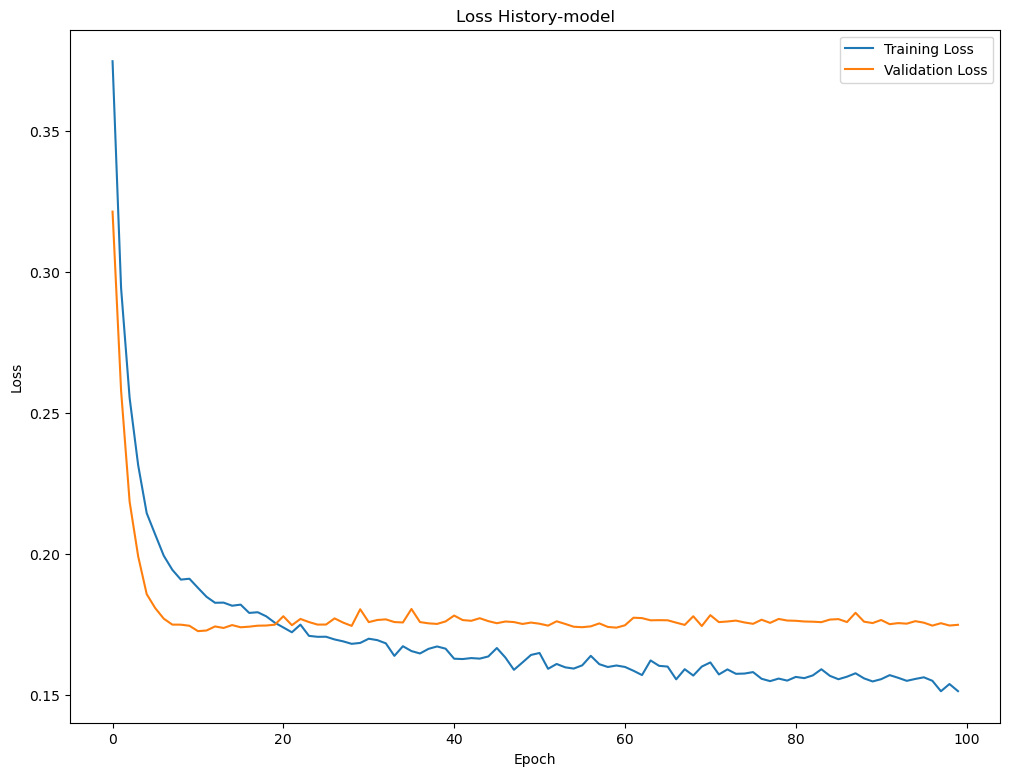

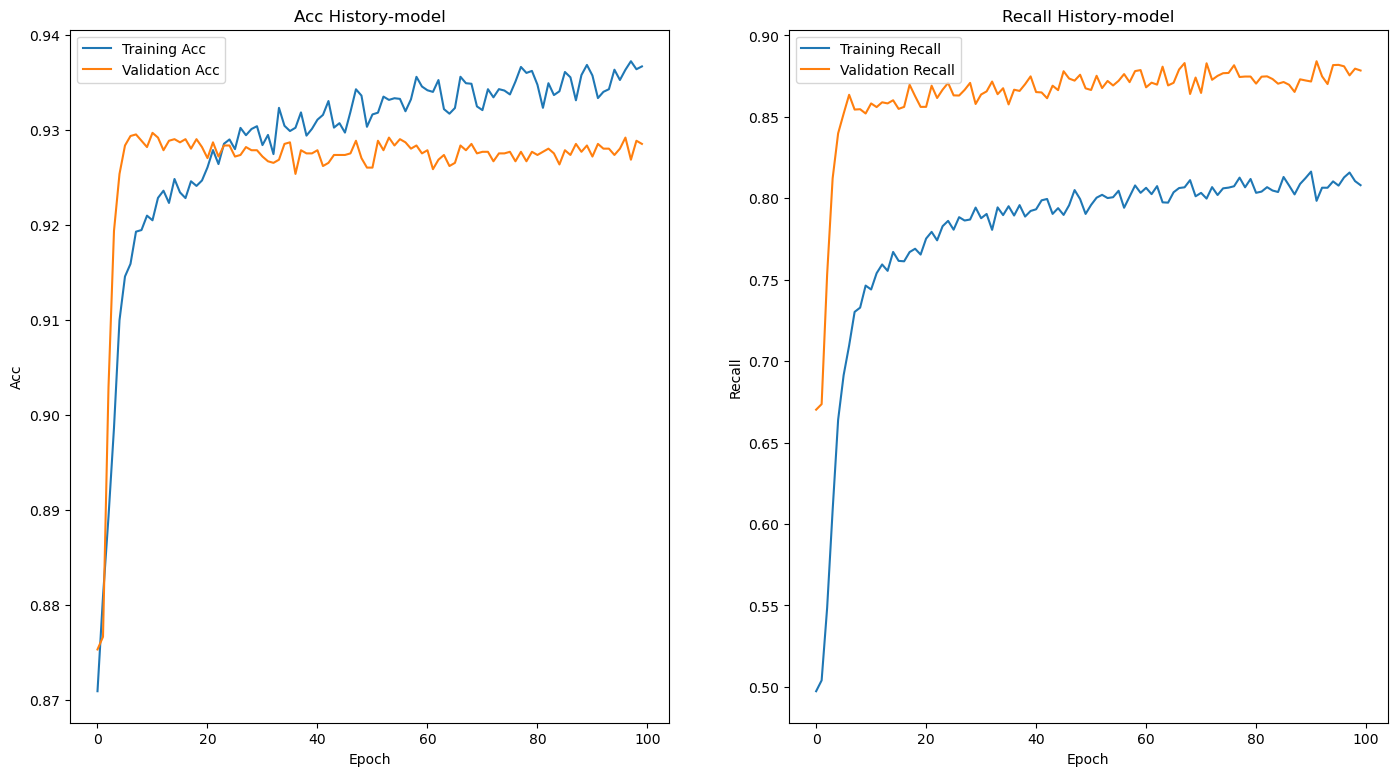

In [60]:
def load_model(path):
    model = build_model()
    model.load_state_dict(torch.load(path))
    model.eval()
    return model

for fold in range(1):
    
    print(f'#'*15)
    print(f'### Fold: {fold}')
    print(f'#'*15)
    run = wandb.init(project='med-classification-resnet50-ax', 
                    config={k:v for k, v in dict(vars(CFG)).items() if '__' not in k},
                    anonymous=anonymous,
                    name=f"fold-{fold}|dim-{CFG.img_size[0]}x{CFG.img_size[1]}|model-{CFG.model_name}",
                    group=CFG.comment,
                    )
    train_loader, valid_loader = train_loader,valid_loader
    model     =   build_model()
    unfreeze_last_n_layers(model, 2)

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CFG.lr, weight_decay=CFG.wd)
    scheduler =  fetch_scheduler(optimizer) 
    # fetch_scheduler(optimizer)
    
    model, history = run_training(model, optimizer, scheduler,
                                device=CFG.device,
                                num_epochs=CFG.epochs)
    # run.finish()
    # display(ipd.IFrame(run.url, width=1000, height=720))
    plt.figure(figsize=(12,9))

    plt.plot(history['Train Loss'], label=f'Training Loss')
    plt.plot(history['Valid Loss'], label=f'Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Loss History-model')


    plt.figure(figsize=(17,9))
    plt.subplot(1, 2, 1)
    plt.plot(history['Train Acc'], label=f'Training Acc')
    plt.plot(history['Valid Acc'], label=f'Validation Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Acc')
    plt.legend()
    plt.title(f'Acc History-model')

    plt.subplot(1, 2, 2)
    plt.plot(history['Train Recall'], label=f'Training Recall')
    plt.plot(history['Valid Recall'], label=f'Validation Recall')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.legend()
    plt.title(f'Recall History-model')
    plt.show()
    torch.save(model.state_dict(), 'ResNet50_ax_state_dict.pth')
    torch.save(model, 'ResNet50_ax.pt')

In [62]:
import GPUtil

gpus = GPUtil.getGPUs()
gpu = gpus[0]
GPUtil.showUtilization()
free_memory = gpu.memoryFree
torch.cuda.empty_cache()
gc.collect()

| ID | GPU | MEM |
------------------
|  0 |  0% | 14% |


9943

# Валидация

In [64]:
import os
device = 'cuda'

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for (sample) in loader:
            inputs, labels = sample['image'],sample['labelS']  
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            print(outputs.size())
            _,preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

# Получение предсказаний для тренировочного и тестового наборов
train_preds, train_labels = get_predictions(model, train_loader)
test_preds, test_labels = get_predictions(model, valid_loader)

torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([128, 2])
torch.Size([1

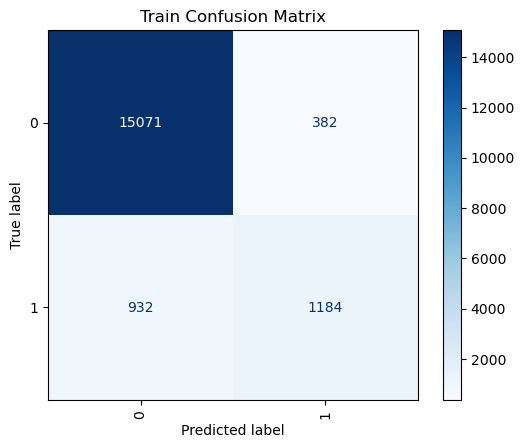

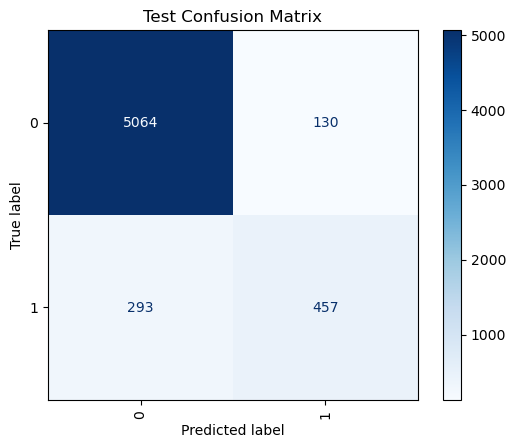

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Функция для отрисовки матрицы путаницы
def plot_confusion_matrix(preds, labels,filename,title='Confusion Matrix'):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.title(title)
    plt.savefig(filename)
    plt.show()

# Отрисовка матрицы путаницы для тренировочного и тестового наборов

plot_confusion_matrix(train_preds, train_labels,  title='Train Confusion Matrix',filename=os.path.join('Model_storage', 'train_confusion_matrix_ax.png'))
plot_confusion_matrix(test_preds, test_labels, title='Test Confusion Matrix',filename=os.path.join('Model_storage', 'val_confusion_matrix_ax.png'))